# Module 5: Churn Prediction Modeling
**Customer Intelligence Platform**

Goal: train Logistic Regression and Random Forest on the Module 4 feature set, compare them properly (not just on accuracy), and save the better model for the FastAPI `/churn-score` endpoint.

## 1: Load Train/Test Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)

train_df = pd.read_csv('../data/processed/churn_train.csv')
test_df = pd.read_csv('../data/processed/churn_test.csv')

feature_cols = ['Frequency_log', 'Monetary_log', 'Tenure', 'AOV_log',
                'Purchase_Variability_log', 'Product_Diversity_log', 'Cluster']
target_col = 'Churned'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print('X_train:', X_train.shape, '| X_test:', X_test.shape)

X_train: (4702, 7) | X_test: (1176, 7)


## 2: Scale Features (for Logistic Regression)

In [2]:
# Fit the scaler on TRAIN only, then transform both -- fitting on test would leak test info into scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3 Train Logistic Regression 

In [3]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## 4: Evaluate Logistic Regression

In [4]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print('Precision:', round(precision_score(y_test, y_pred_lr), 4))
print('Recall:', round(recall_score(y_test, y_pred_lr), 4))
print('F1:', round(f1_score(y_test, y_pred_lr), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_lr), 4))

Precision: 0.6125
Recall: 0.7542
F1: 0.676
ROC-AUC: 0.8114


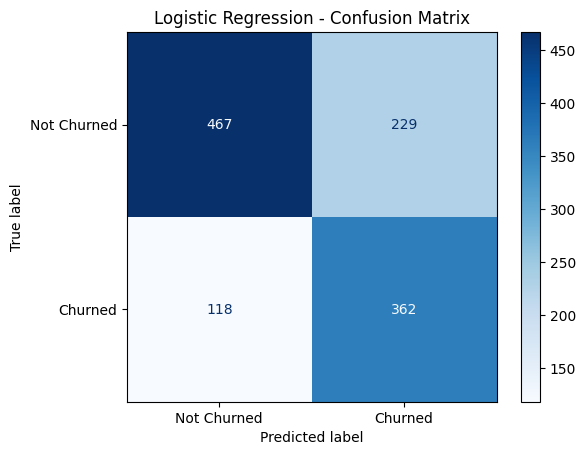

In [5]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Not Churned', 'Churned']).plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.savefig('../images/logreg_confusion_matrix.png', dpi=100)
plt.show()

## 5: Train Random Forest

In [6]:
# Random Forest splits on raw thresholds, so it doesn't need scaled inputs
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 6: Evaluate Random Forest

In [7]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Precision:', round(precision_score(y_test, y_pred_rf), 4))
print('Recall:', round(recall_score(y_test, y_pred_rf), 4))
print('F1:', round(f1_score(y_test, y_pred_rf), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_rf), 4))

Precision: 0.7243
Recall: 0.6896
F1: 0.7065
ROC-AUC: 0.8454


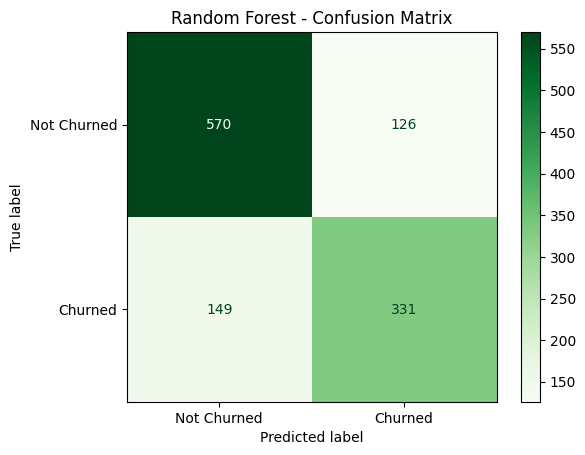

In [8]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Not Churned', 'Churned']).plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.savefig('../images/rf_confusion_matrix.png', dpi=100) 
plt.show()

## 7: Compare Models & Feature Importance

In [9]:
comparison = pd.DataFrame({
    'Logistic Regression': [
        precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_proba_lr)
    ],
    'Random Forest': [
        precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_proba_rf)
    ]
}, index=['Precision', 'Recall', 'F1', 'ROC-AUC']).round(4)

comparison

,Logistic Regression,Random Forest
Precision,0.6125,0.7243
Recall,0.7542,0.6896
F1,0.6760,0.7065
ROC-AUC,0.8114,0.8454


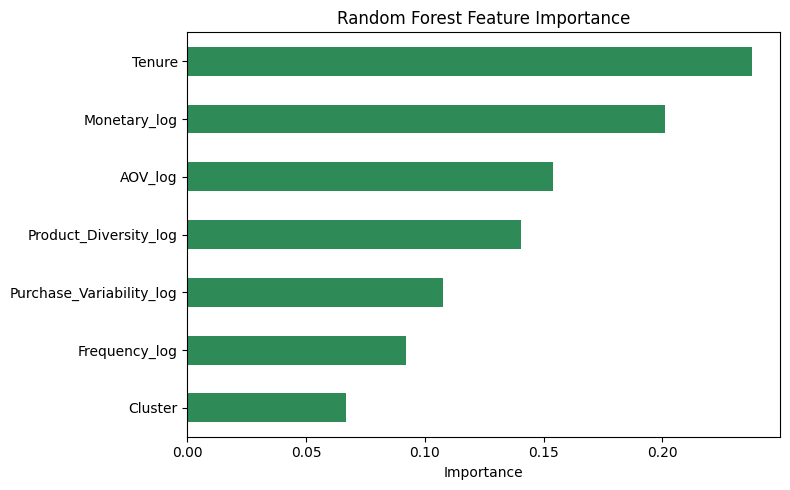

Tenure                      0.237698
Monetary_log                0.201226
AOV_log                     0.154113
Product_Diversity_log       0.140667
Purchase_Variability_log    0.107551
Frequency_log               0.092055
Cluster                     0.066689
dtype: float64

In [10]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)


plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../images/rf_feature_importance.png', dpi=100)
plt.show()

importances

**Reading the comparison:**

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Precision | 0.6125 | 0.7243 |
| Recall | 0.7542 | 0.6896 |
| F1 | 0.6760 | 0.7065 |
| ROC-AUC | 0.8114 | 0.8454 |

Logistic Regression catches slightly more actual churners (recall 75.4% vs 69.0% — 362 vs 331 true positives, a difference of 31 customers). But it does this at the cost of **229 false alarms vs Random Forest's 126** — nearly double. So for those extra 31 churners caught, Logistic Regression flags 103 more healthy customers as at-risk. Random Forest also has a clearly better F1 and a notably better ROC-AUC (0.845 vs 0.811 — meaningful, since AUC reflects how well the model ranks customers by risk, which matters a lot if the business wants to prioritize a 'top N at-risk customers' retention list rather than a hard yes/no cutoff).

**Decision: Random Forest** — the small recall gap from Logistic Regression isn't worth roughly double the false-alarm rate, and its stronger AUC makes it more useful for ranking-based retention targeting.

**Feature importance** also lines up with intuition: `Tenure` and `Monetary_log` are the strongest drivers of churn — long-tenured, high-spending customers are the least likely to churn, which matches the segment story from Module 3 (`Loyal High-Value Customers` had the lowest churn rate).

## Step 8: Save Best Model

In [ ]:
joblib.dump(rf, '../models/churn_model.pkl')
print('Saved churn_model.pkl to models/')

Saved churn_model.pkl to models/


### Module 5 Summary

- **Logistic Regression:** Precision 0.61, Recall 0.75, F1 0.68, ROC-AUC 0.81 (scaled features, `class_weight='balanced'`)
- **Random Forest:** Precision 0.72, Recall 0.69, F1 0.71, ROC-AUC 0.85 (raw features, `class_weight='balanced'`)
- **Chosen model: Random Forest** — better F1 and notably better ROC-AUC; Logistic Regression's slightly higher recall came at the cost of nearly double the false-alarm rate
- **Top churn drivers:** `Tenure` and `Monetary_log` — customers with longer tenure and higher total spend are far less likely to churn, consistent with the K-Means segment story from Module 3
- Saved `churn_model.pkl` to `models/` — ready for the FastAPI `/churn-score` endpoint
